In [1]:
# ── Cell 1: Setup & load database ──
import sys, os, time
import numpy as np
import pandas as pd
import json
import gc

REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(REPO, 'Code', 'tools'))

DATA_ROOT = os.path.join(REPO, '..', '..', 'Data', 'Geospatial')
JSON_ROOT = os.path.join(REPO, '..', '..', 'Data', 'CT JSON')
DB_INPUT  = os.path.join(DATA_ROOT, 'geoteryt_plotting.pkl')

REPLICATE_ROOT = os.path.join(REPO, '..', '..', 'Data', 'replication_package', 'geometry')
import geoTERYT_db as gtdb

print(f"Loading database from: {DB_INPUT}")
t0 = time.time()
db = gtdb.load_complete_database(DB_INPUT, verbose=True, if_full=False)
elapsed = time.time() - t0
print(f"\nLoaded in {elapsed:.1f}s — {len(db._records)} records")

gc.collect()

Loading database from: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper/../../Data/Geospatial/geoteryt_plotting.pkl
Loading complete database from /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper/../../Data/Geospatial/geoteryt_plotting.pkl...
  Database version: 4.3
  ✓ Restored old voivodships: 49 rows
  ✓ Restored geometry store: 13,287 unique geometries
  ✓ Restored geometry data for years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  ✓ Loaded 4613 records
  ✓ Year range: 1999 - 2024
  ✓ Records with geometry: 3662
  ✓ Records with old_woj: 4104
  ✓ Records with population data: 4590
  ✓ Records with pop_class: 4542

Loaded in 11.8s — 4613 records


0

In [2]:
# Imports
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely as sh

In [3]:
# First geometries for voivodeships
# OLD
region_gdf = gpd.GeoDataFrame()

for id in range(1,50):
    teryt = f"{100-id}00000"
    rec = db.get_by_teryt_id(teryt)
    region_gdf = pd.concat([region_gdf, gpd.GeoDataFrame({'id': [id],
                                                          'teryt_id': [teryt],
                                                          'name': [rec.name],
                                                          'if_new': [False],
                                                          'if_old': [True],
                                                          'if_LIS_macro': [False],
                                                          'if_CBOS_macro': [False],
                                                          'geometry': [rec.geometry]})], ignore_index=True)

# NEW
i=1
geo = db.merge_to_level(year = 2005, target_level= 2)
for id in range(2,34,2):
    teryt = str(id).zfill(2) + "00000"
    rec = db.get_by_teryt_id(teryt)
    region_gdf = pd.concat([region_gdf, gpd.GeoDataFrame({'id': [i],
                                                          'teryt_id': [teryt],
                                                          'name': [rec.name],
                                                          'if_new': [True],
                                                          'if_old': [False],
                                                          'if_LIS_macro': [False],
                                                          'if_CBOS_macro': [False],
                                                          'geometry': [geo.iloc[i-1].geometry]})], ignore_index=True)
    i+=1


# Create geometries for LIS macroregions

lis_macroregions = {1: ['5800000', '9400000', '7500000', '6900000', '6700000'],
                    2: ['9800000', '5200000', '7700000', '6400000'],
                    3: ['9200000', '9100000', '8400000', '6200000', '6300000'],
                    4: ['9700000', '9300000', '8700000', '7600000'],
                    5: ['8600000', '8300000', '8200000', '7800000', '7100000', '6800000', '6100000', '6000000'],
                    6: ['9900000', '9500000', '7900000', '5400000'],
                    7: ['5100000', '7300000', '7000000', '6600000', '6500000'],
                    8: ['9600000', '8800000', '8500000', '8000000', '7400000', '7200000', '5900000', '5500000'],
                    9: ['9000000', '8900000', '8100000', '5700000', '5600000', '5300000']
                    }

lis_macroregions_dict = {
    1: "Central",
    2: "North-East",
    3: "North",
    4: "South",
    5: "South-East",
    6: "Middle-East",
    7: "Middle",
    8: "Middle-West",
    9: "South-West"
}

_tol = 10  # metres – bridges sub-pixel edge mismatches between voivodeships
for id in range(1,10):
    voivs = lis_macroregions[id]
    pieces = [db.get_by_teryt_id(t).geometry for t in voivs]
    geometry = sh.unary_union([p.buffer(_tol) for p in pieces]).buffer(-_tol)
    region_gdf = pd.concat([region_gdf, gpd.GeoDataFrame({'id': [id],
                                                          'teryt_id': [None],
                                                          'name': [lis_macroregions_dict[id]],
                                                          'if_new': [False],
                                                          'if_old': [False],
                                                          'if_LIS_macro': [True],
                                                          'if_CBOS_macro': [False],
                                                          'geometry': [geometry]})], ignore_index=True)

# Create geometries for CBOS macroregions

cbos_macroregions = {1: ['1400000', '1000000'],
                     2: ['1200000', '2400000'],
                     3: ['0600000', '1800000', '2000000', '2600000'],
                     4: ['3000000', '3200000', '0800000'],
                     5: ['0200000', '1600000'],
                     6: ['2200000', '2800000', '0400000']
                     }

cbos_macroregions_dict = {
    1: "Central",
    2: "South",
    3: "East",
    4: "North-West",
    5: "South-West",
    6: "North"
}

for id in range(1,7):
    voivs = cbos_macroregions[id]
    pieces = [geo.loc[geo['teryt_id'] == t].geometry.iloc[0] for t in voivs]
    geometry = sh.unary_union([p.buffer(_tol) for p in pieces]).buffer(-_tol)
    region_gdf = pd.concat([region_gdf, gpd.GeoDataFrame({'id': [id],
                                                          'teryt_id': [None],
                                                          'name': [cbos_macroregions_dict[id]],
                                                          'if_new': [False],
                                                          'if_old': [False],
                                                          'if_LIS_macro': [False],
                                                          'if_CBOS_macro': [True],
                                                          'geometry': [geometry]})], ignore_index=True)

region_gdf.crs = db._crs

<Axes: >

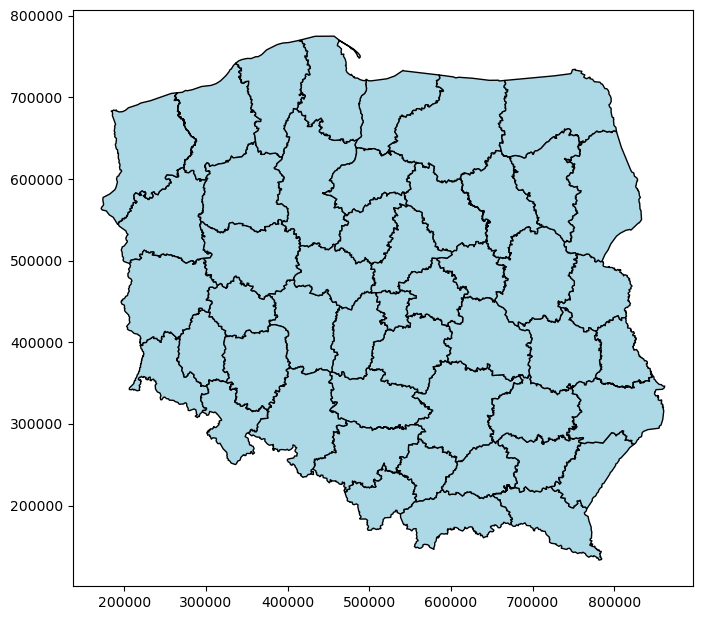

In [4]:
test_col = ['if_new', 'if_old', 'if_LIS_macro', 'if_CBOS_macro'][1]
region_gdf[region_gdf[test_col]].plot(figsize=(8,8), edgecolor='black', color='lightblue')

In [5]:
# Load the old voiv groups
json_path = "/Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/reweighing/U_old_voiv_dict.json"

with open(json_path, 'r') as f:
    old_voiv_groups = json.load(f)
    
# Old voiv shapes
old_voiv = region_gdf[region_gdf['if_old']]

In [6]:
description_dict_5 = {
    1: "village",
    2: "city below 20k",
    3: "city 20k-100k",
    4: "city 100k-500k",
    5: "city above 500k"
}
description_dict_6 = {
    1: "village",
    2: "city below 20k",
    3: "city 20k-100k",
    4: "city 100k-200k",
    5: "city 200k-500k",
    6: "city above 500k"
}

In [7]:
group_gdf = gpd.GeoDataFrame()
_tol = 8

i=1
total = len(old_voiv_groups)
t0 = time.time()
for group, teryts in old_voiv_groups.items():
    keys = pd.DataFrame(old_voiv_groups[group]['keys'])
    voiv_keys = keys[0].unique()
    
    if 6 in keys[3].unique():
        description_dict = description_dict_6
    else:
        description_dict = description_dict_5
        
    description_key = keys[3].map(description_dict).unique()
    
    if len(voiv_keys) == 1:
        voiv_key = voiv_keys[0]
    else:
        if len(teryts['array']) > 0:
            print(f"Group {group} has multiple voivodeship keys: {voiv_keys}")
        else:
            print(f"Group {group} has no teryts, skipping.")
            continue
        
    
    teryt_id = str(voiv_key) + "00000"
    voiv_geometry = db.get_by_teryt_id(teryt_id).geometry
    gminas_geometries = []
    for t in teryts['array']:
        geom = db.get_geometry(t, year = 1999)
        if geom is not None:
            gminas_geometries.append(geom.buffer(_tol))
        else:
            print(f"Geometry for teryt {t} not found.")
    gminas_geometries = sh.unary_union(gminas_geometries).buffer(-_tol)
    group_geometry = gminas_geometries
    #group_geometry = voiv_geometry.intersection(gminas_geometries)
    group_gdf = pd.concat([group_gdf, gpd.GeoDataFrame({'id': [group],
                                                        'teryt_id': [teryt_id],
                                                        'name': ', '.join(description_key) + " in " + db.get_by_teryt_id(teryt_id).name.strip().lower().title(),
                                                        'if_1': [1 in keys[3].unique()],
                                                        'if_2': [2 in keys[3].unique()],
                                                        'if_5': [5 in keys[3].unique()],
                                                        'if_15': [15 in keys[3].unique()],
                                                        'if_125': [125 in keys[3].unique()],
                                                        'if_new': [False],
                                                        'if_old': [True],
                                                        'if_LIS_macro': [False],
                                                        'if_CBOS_macro': [False],
                                                        'geometry': [group_geometry]})], ignore_index=True)
    if i % 10 == 0:
        print(f"Processed {i}/{total} groups ({i/total:.1%}). Elapsed: {time.time() - t0:.1f}s — Estimated total: {(time.time() - t0)/i*total:.1f}s")
    i+=1                                                                                                    

Group Group 2 has no teryts, skipping.
Processed 10/125 groups (8.0%). Elapsed: 7.4s — Estimated total: 91.9s
Processed 20/125 groups (16.0%). Elapsed: 19.5s — Estimated total: 121.8s
Processed 30/125 groups (24.0%). Elapsed: 30.2s — Estimated total: 125.8s
Processed 40/125 groups (32.0%). Elapsed: 31.6s — Estimated total: 98.6s
Processed 50/125 groups (40.0%). Elapsed: 55.7s — Estimated total: 139.2s
Processed 60/125 groups (48.0%). Elapsed: 63.2s — Estimated total: 131.7s
Processed 70/125 groups (56.0%). Elapsed: 73.0s — Estimated total: 130.4s
Processed 80/125 groups (64.0%). Elapsed: 96.3s — Estimated total: 150.5s
Processed 90/125 groups (72.0%). Elapsed: 116.7s — Estimated total: 162.0s
Processed 100/125 groups (80.0%). Elapsed: 128.8s — Estimated total: 161.0s
Processed 110/125 groups (88.0%). Elapsed: 134.6s — Estimated total: 153.0s
Processed 120/125 groups (96.0%). Elapsed: 145.8s — Estimated total: 151.9s


/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_48859/1421932892.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


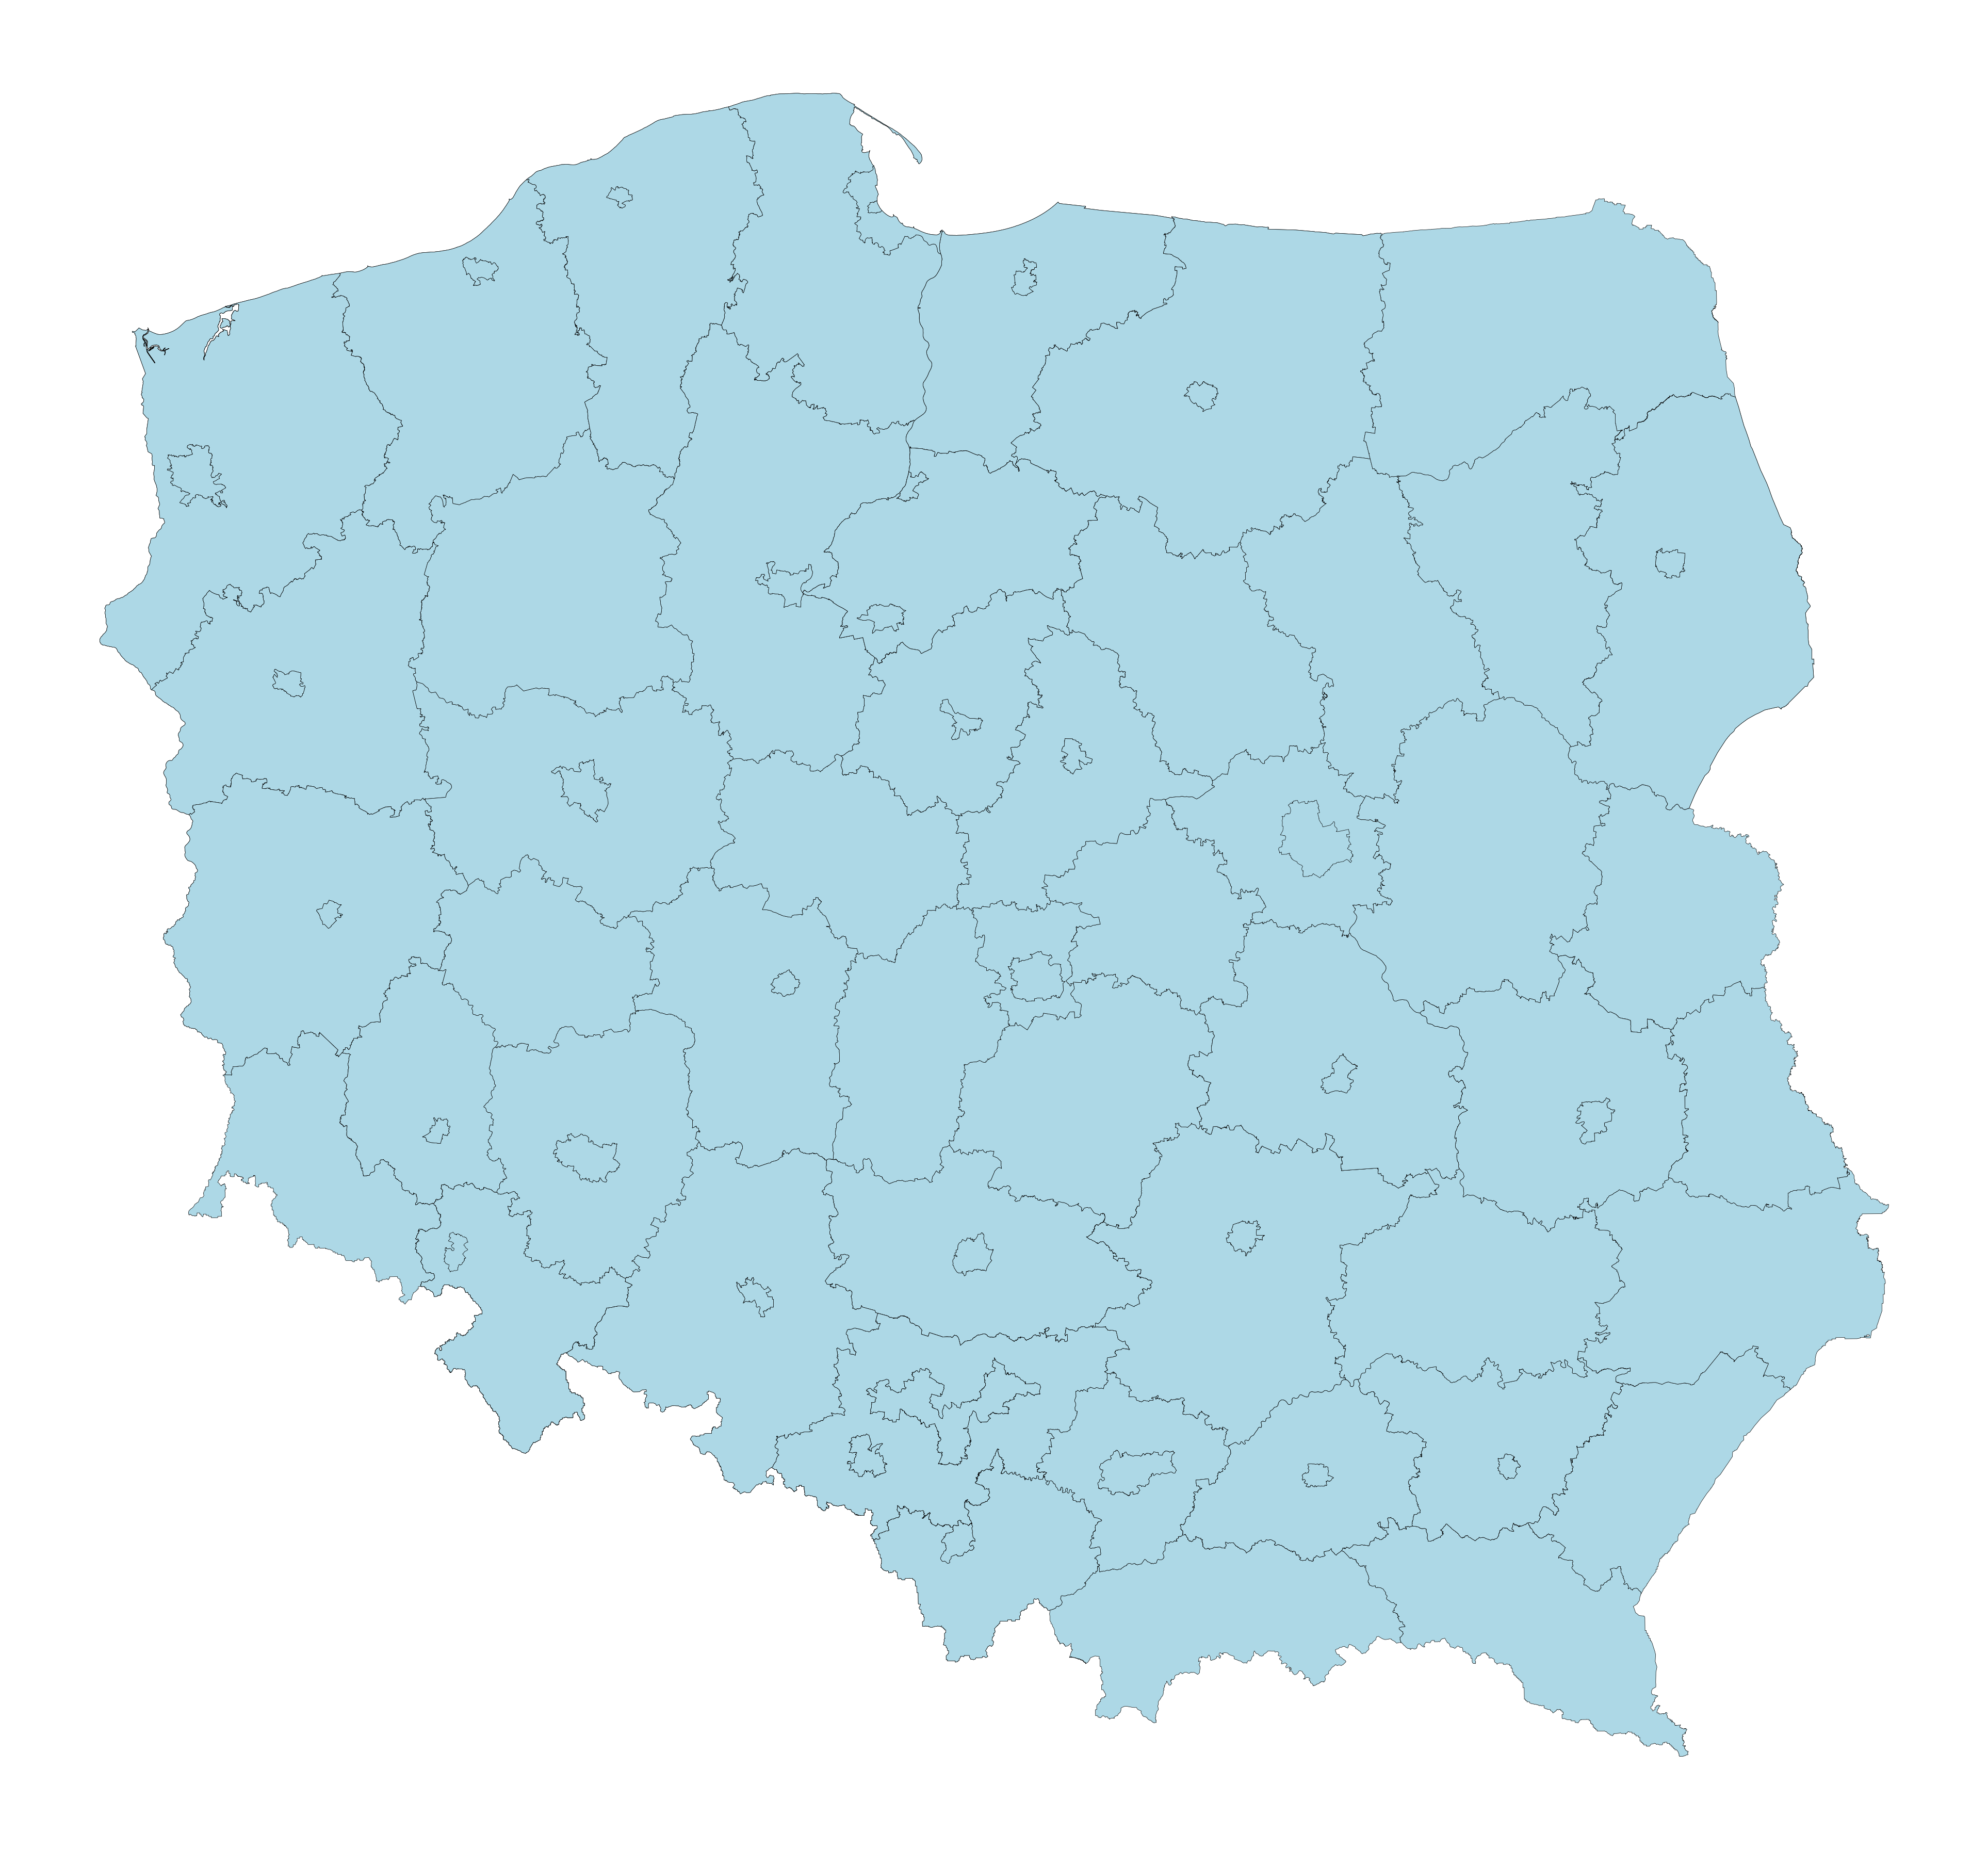

In [8]:
# Plot
fig, ax = plt.subplots(figsize=(20,20), dpi = 200)
group_gdf[group_gdf['if_old']].plot(ax=ax, edgecolor='black', color='lightblue', linewidth=0.25)
fig.tight_layout()
ax.set_axis_off()
fig.show()


In [9]:
# Load the new voiv groups
json_path = "/Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/reweighing/U_new_voiv_dict.json"

with open(json_path, 'r') as f:
    new_voiv_groups = json.load(f)
    
# New voiv shapes
new_voiv = region_gdf[region_gdf['if_new']]

In [10]:
_tol = 8

i=1
total = len(new_voiv_groups)
t0 = time.time()
for group, teryts in new_voiv_groups.items():
    keys = pd.DataFrame(new_voiv_groups[group]['keys'])
    voiv_keys = keys[0].unique()
    
    if 6 in keys[3].unique():
        description_dict = description_dict_6
    else:
        description_dict = description_dict_5
        
    description_key = keys[3].map(description_dict).unique()
    
    if len(voiv_keys) == 1:
        voiv_key = voiv_keys[0]
    else:
        if len(teryts['array']) > 0:
            print(f"Group {group} has multiple voivodeship keys: {voiv_keys}")
        else:
            print(f"Group {group} has no teryts, skipping.")
            continue
        
    
    teryt_id = str(voiv_key).zfill(2) + "00000"
    voiv_geometry = new_voiv.loc[new_voiv['teryt_id'] == teryt_id].geometry.values[0]
    gminas_geometries = []
    for t in teryts['array']:
        geom = db.get_geometry(t, year = 2005)
        if geom is not None:
            gminas_geometries.append(geom.buffer(_tol))
        else:
            print(f"Geometry for teryt {t} not found.")
    gminas_geometries = sh.unary_union(gminas_geometries).buffer(-_tol)
    group_geometry = gminas_geometries
    #group_geometry = voiv_geometry.intersection(gminas_geometries)
    group_gdf = pd.concat([group_gdf, gpd.GeoDataFrame({'id': [group],
                                                        'teryt_id': [teryt_id],
                                                        'name': ', '.join(description_key) + " in " + db.get_by_teryt_id(teryt_id).name.strip().lower().title(),
                                                        'if_1': [1 in keys[3].unique()],
                                                        'if_2': [2 in keys[3].unique()],
                                                        'if_5': [5 in keys[3].unique()],
                                                        'if_15': [15 in keys[3].unique()],
                                                        'if_125': [125 in keys[3].unique()],
                                                        'if_new': [True],
                                                        'if_old': [False],
                                                        'if_LIS_macro': [False],
                                                        'if_CBOS_macro': [False],
                                                        'geometry': [group_geometry]})], ignore_index=True)
    if i % 10 == 0:
        print(f"Processed {i}/{total} groups ({i/total:.1%}). Elapsed: {time.time() - t0:.1f}s — Estimated total: {(time.time() - t0)/i*total:.1f}s")
    i+=1                                                                        

Group Group 5 has no teryts, skipping.
Processed 10/291 groups (3.4%). Elapsed: 2.9s — Estimated total: 85.2s
Processed 20/291 groups (6.9%). Elapsed: 8.3s — Estimated total: 121.0s
Processed 30/291 groups (10.3%). Elapsed: 14.0s — Estimated total: 136.2s
Processed 40/291 groups (13.7%). Elapsed: 17.2s — Estimated total: 125.1s
Processed 50/291 groups (17.2%). Elapsed: 23.5s — Estimated total: 137.0s
Processed 60/291 groups (20.6%). Elapsed: 39.6s — Estimated total: 192.1s
Processed 70/291 groups (24.1%). Elapsed: 48.8s — Estimated total: 202.8s
Processed 80/291 groups (27.5%). Elapsed: 59.5s — Estimated total: 216.6s
Processed 90/291 groups (30.9%). Elapsed: 70.2s — Estimated total: 227.1s
Processed 100/291 groups (34.4%). Elapsed: 84.5s — Estimated total: 246.0s
Processed 110/291 groups (37.8%). Elapsed: 107.7s — Estimated total: 284.8s
Processed 120/291 groups (41.2%). Elapsed: 113.8s — Estimated total: 275.9s
Processed 130/291 groups (44.7%). Elapsed: 125.7s — Estimated total: 281.

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_48859/151501382.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


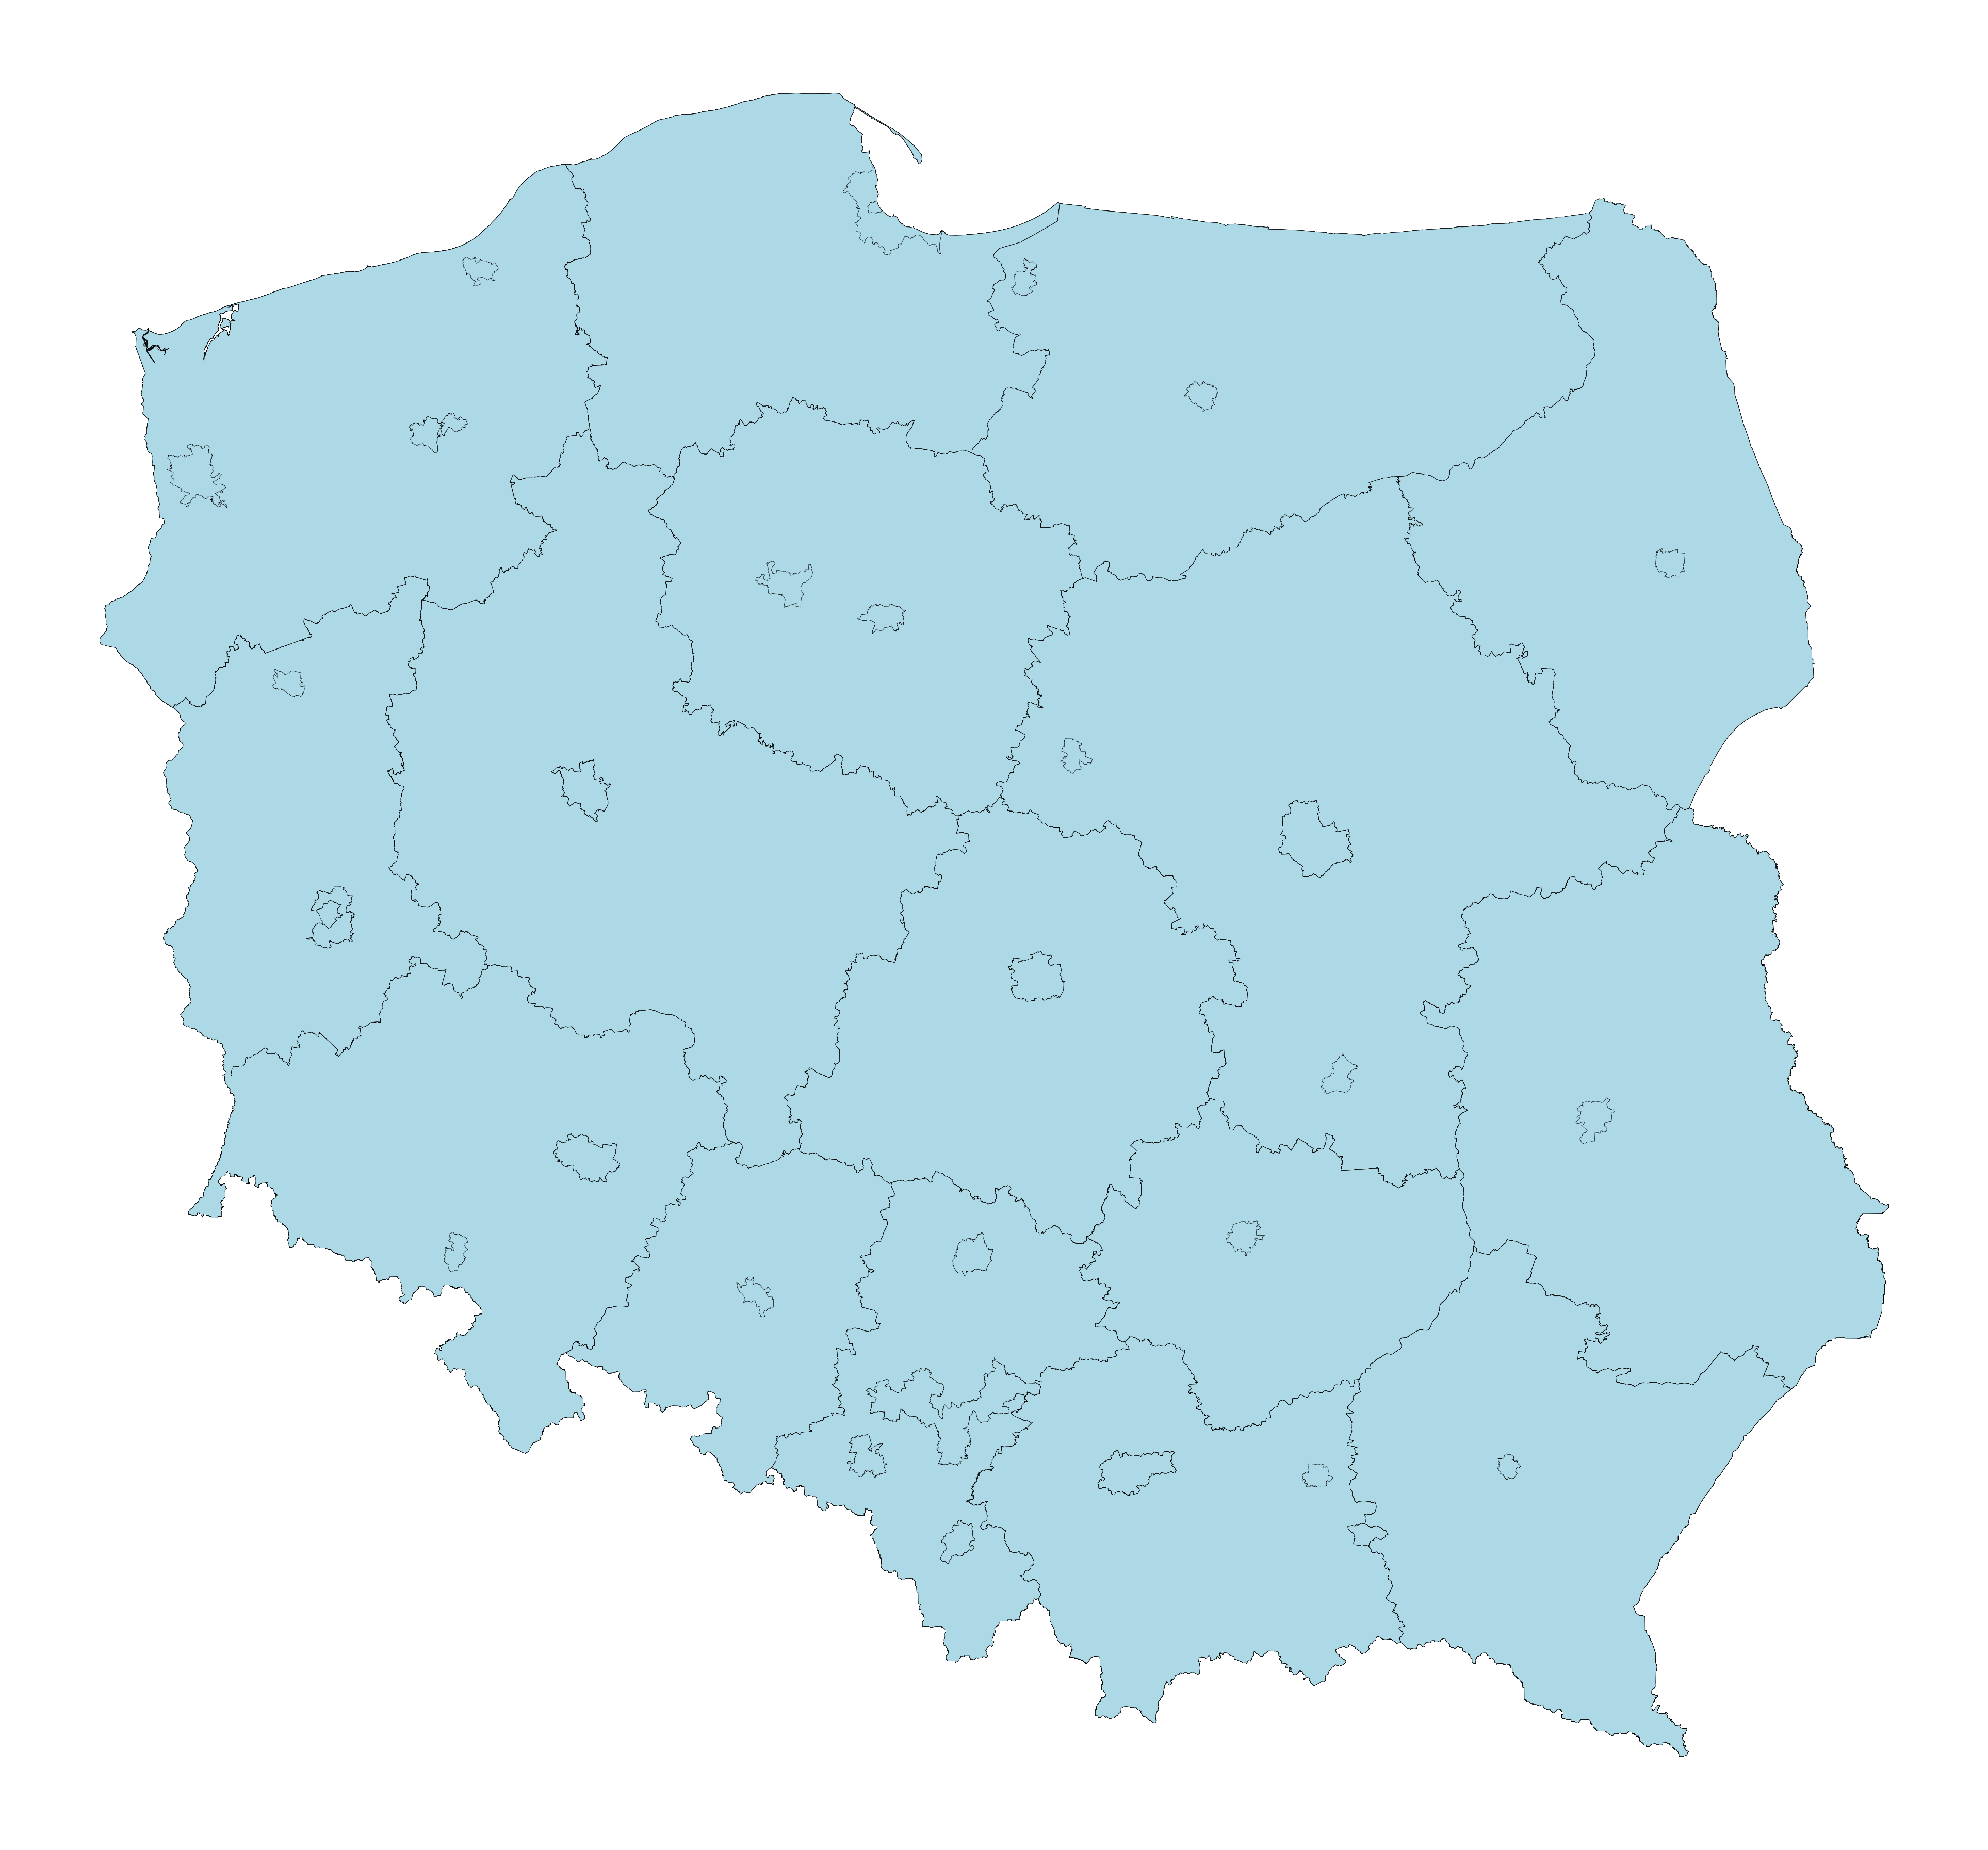

In [11]:
# Plot
fig, ax = plt.subplots(figsize=(20,20), dpi = 200)
group_gdf[group_gdf['if_new']].plot(ax=ax, edgecolor='black', color='lightblue', linewidth=0.25)
fig.tight_layout()
ax.set_axis_off()
fig.show()


In [12]:
# Load the lis macro groups
json_path = "/Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/reweighing/U_lis_macroregions_dict.json"

with open(json_path, 'r') as f:
    lis_macro_groups = json.load(f)
    
# Lis macro shapes
lis_macro = region_gdf[region_gdf['if_LIS_macro']]

In [13]:
group_gdf = gpd.GeoDataFrame()
_tol = 8

i=1
total = len(lis_macro_groups)
t0 = time.time()
for group, teryts in lis_macro_groups.items():
    keys = pd.DataFrame(lis_macro_groups[group]['keys'])
    voiv_keys = keys[0].unique()
    
    if 6 in keys[3].unique():
        description_dict = description_dict_6
    else:
        description_dict = description_dict_5
        
    description_key = keys[3].map(description_dict).unique()
    
    if len(voiv_keys) == 1:
        voiv_key = voiv_keys[0]
    else:
        if len(teryts['array']) > 0:
            print(f"Group {group} has multiple voivodeship keys: {voiv_keys}")
        else:
            print(f"Group {group} has no teryts, skipping.")
            continue
        
    
    teryt_id = str(voiv_key)
    voiv_geometry = lis_macro[lis_macro['id'] == voiv_key].geometry.values[0]
    gminas_geometries = []
    for t in teryts['array']:
        geom = db.get_geometry(t, year = 1999)
        if geom is not None:
            gminas_geometries.append(geom.buffer(_tol))
        else:
            print(f"Geometry for teryt {t} not found.")
    gminas_geometries = sh.unary_union(gminas_geometries).buffer(-_tol)
    group_geometry = gminas_geometries
    #group_geometry = voiv_geometry.intersection(gminas_geometries)
    group_gdf = pd.concat([group_gdf, gpd.GeoDataFrame({'id': [group],
                                                        'teryt_id': [teryt_id],
                                                        'name': ', '.join(description_key) + " in " + lis_macro[lis_macro['id'] == voiv_key]['name'].values[0],
                                                        'if_1': [1 in keys[3].unique()],
                                                        'if_2': [2 in keys[3].unique()],
                                                        'if_5': [5 in keys[3].unique()],
                                                        'if_15': [15 in keys[3].unique()],
                                                        'if_125': [125 in keys[3].unique()],
                                                        'if_new': [False],
                                                        'if_old': [False],
                                                        'if_LIS_macro': [True],
                                                        'if_CBOS_macro': [False],
                                                        'geometry': [group_geometry]})], ignore_index=True)
    if i % 10 == 0:
        print(f"Processed {i}/{total} groups ({i/total:.1%}). Elapsed: {time.time() - t0:.1f}s — Estimated total: {(time.time() - t0)/i*total:.1f}s")
    i+=1                                                                                

Group Group 4 has no teryts, skipping.
Processed 10/87 groups (11.5%). Elapsed: 35.2s — Estimated total: 306.5s
Processed 20/87 groups (23.0%). Elapsed: 73.2s — Estimated total: 318.4s
Processed 30/87 groups (34.5%). Elapsed: 79.1s — Estimated total: 229.4s
Processed 40/87 groups (46.0%). Elapsed: 134.1s — Estimated total: 291.6s
Processed 50/87 groups (57.5%). Elapsed: 179.2s — Estimated total: 311.8s
Processed 60/87 groups (69.0%). Elapsed: 201.6s — Estimated total: 292.4s
Processed 70/87 groups (80.5%). Elapsed: 230.1s — Estimated total: 286.0s
Processed 80/87 groups (92.0%). Elapsed: 248.9s — Estimated total: 270.7s


/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_48859/878363662.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


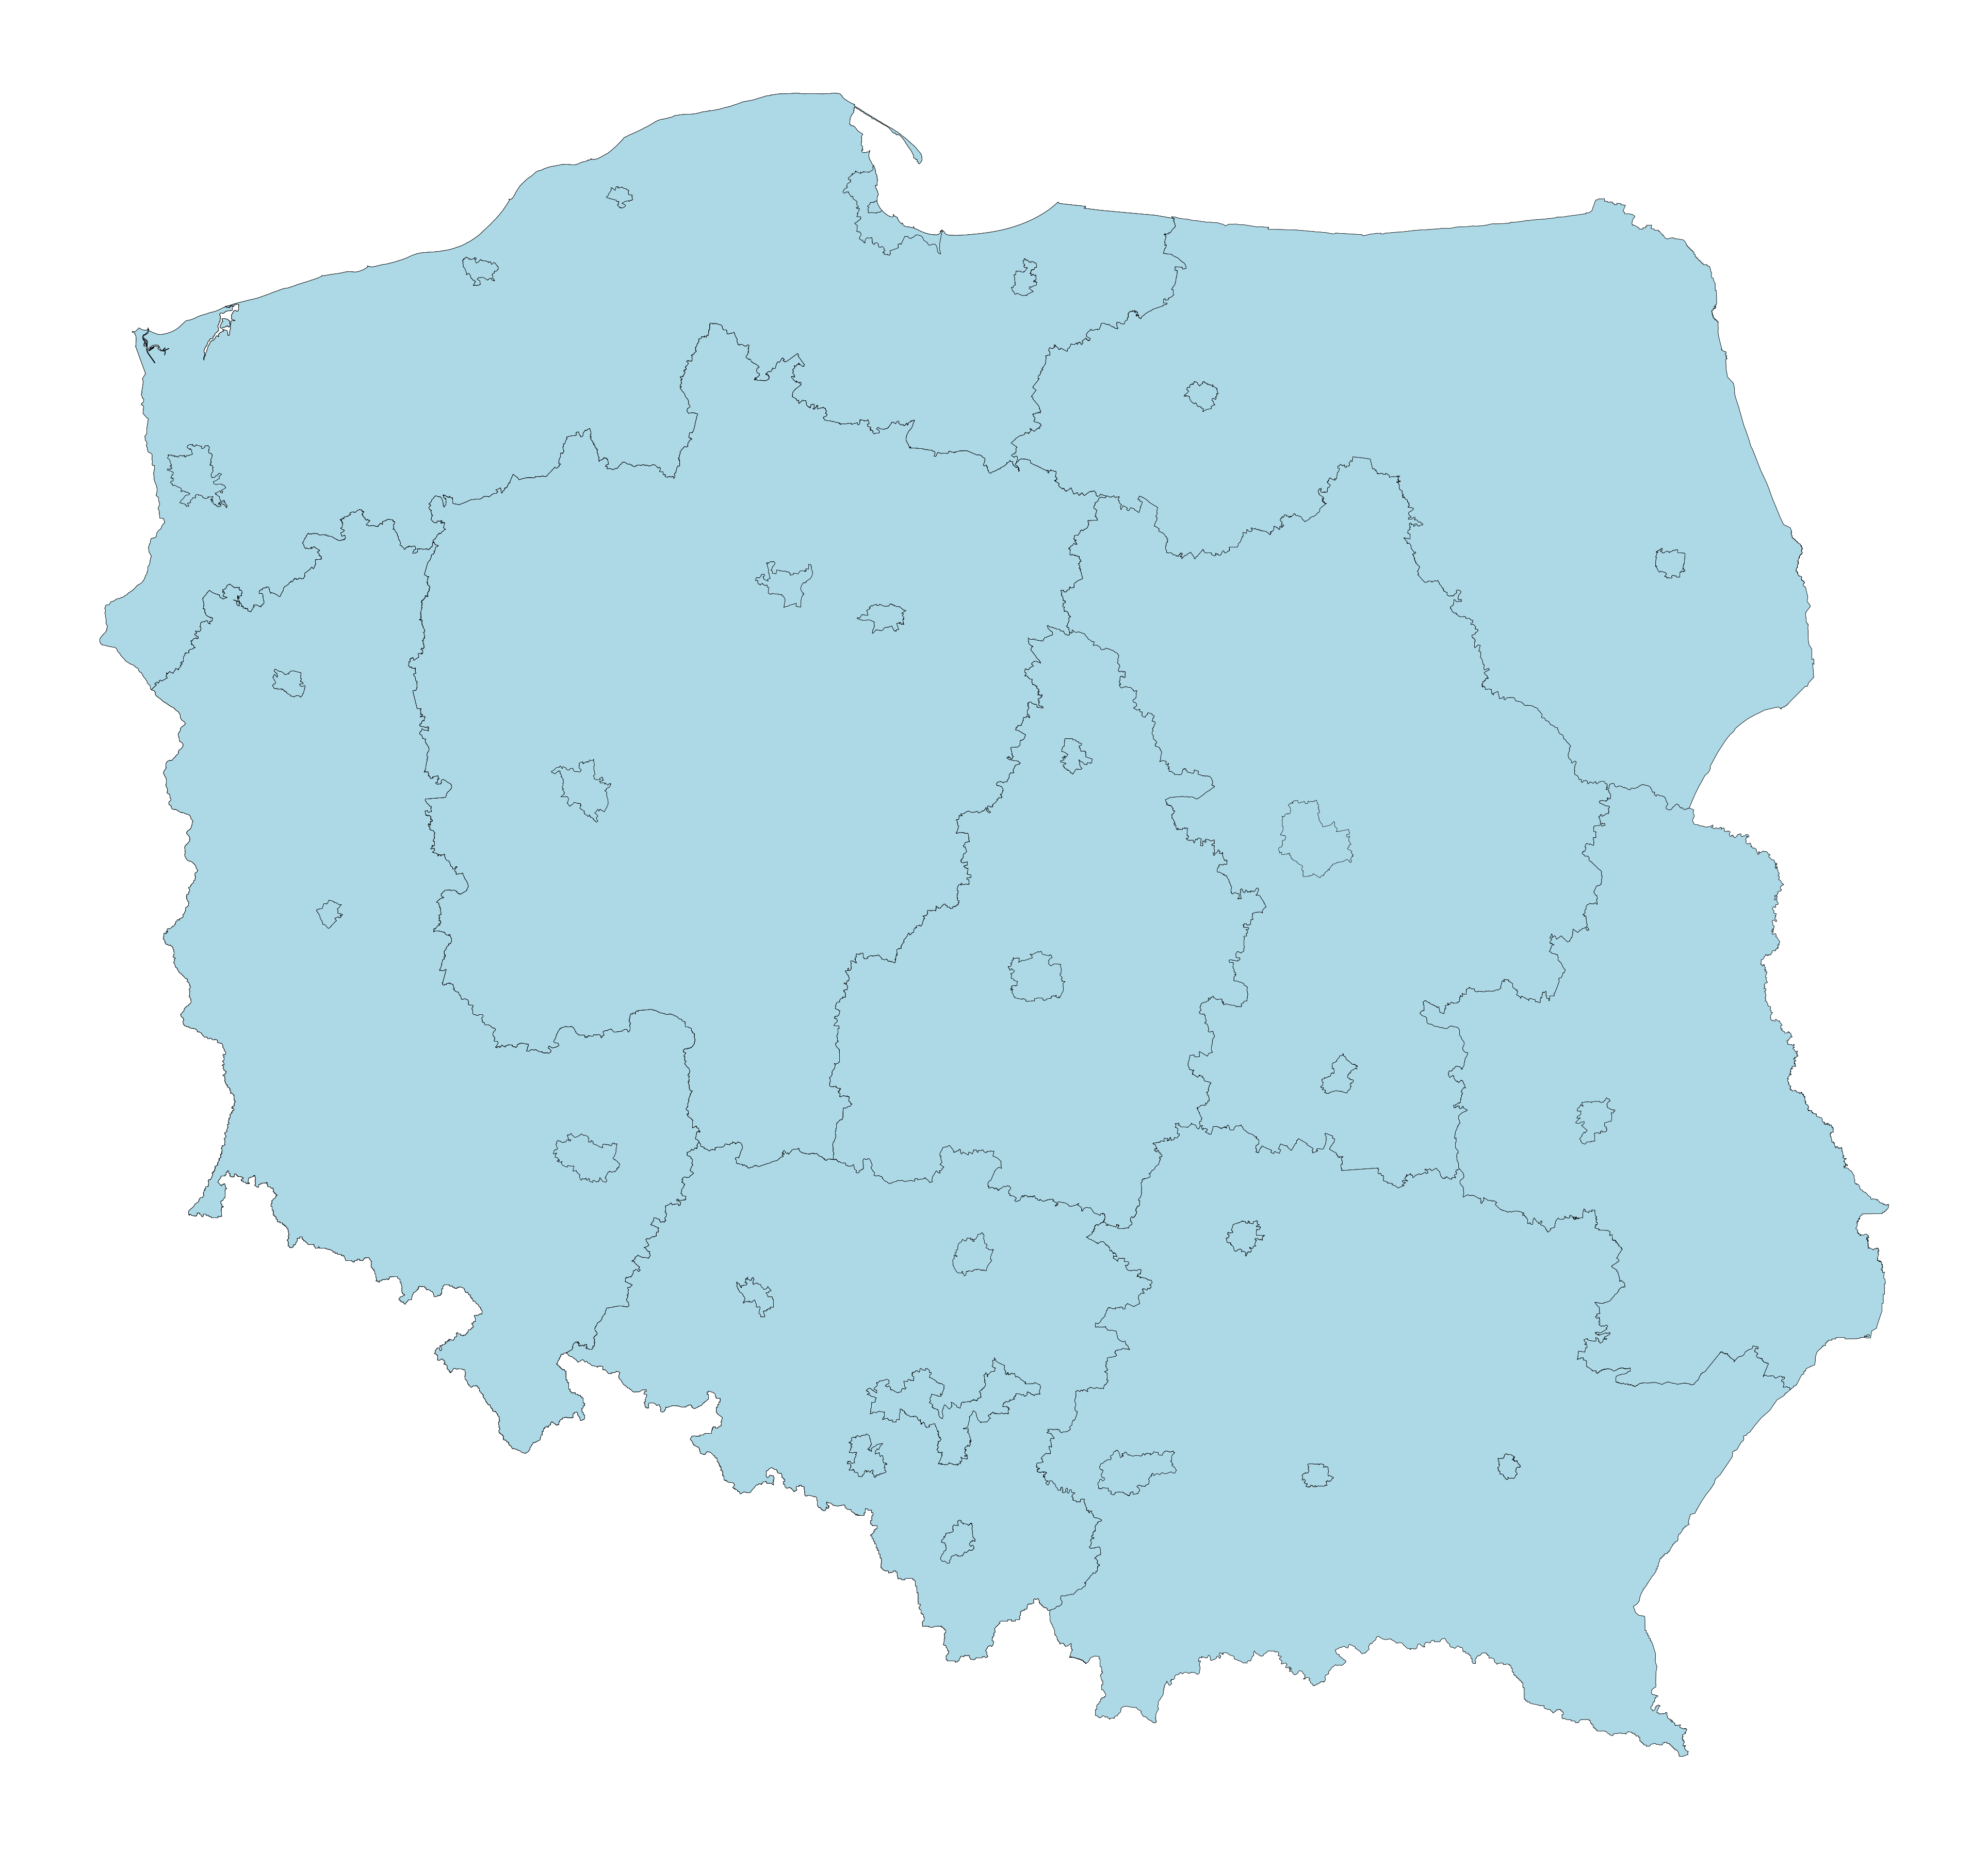

In [14]:
# Plot
fig, ax = plt.subplots(figsize=(20,20), dpi = 200)
group_gdf[group_gdf['if_LIS_macro']].plot(ax=ax, edgecolor='black', color='lightblue', linewidth=0.25)
fig.tight_layout()
ax.set_axis_off()
fig.show()


In [15]:
# Load the lis macro groups
json_path = "/Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/reweighing/U_cbos_macroregions_dict.json"

with open(json_path, 'r') as f:
    cbos_macro_groups = json.load(f)
    
# Lis macro shapes
cbos_macro = region_gdf[region_gdf['if_CBOS_macro']]

In [16]:
_tol = 8

i=1
total = len(cbos_macro_groups)
t0 = time.time()
for group, teryts in cbos_macro_groups.items():
    keys = pd.DataFrame(cbos_macro_groups[group]['keys'])
    voiv_keys = keys[0].unique()
    
    if 6 in keys[3].unique():
        description_dict = description_dict_6
    else:
        description_dict = description_dict_5
        
    description_key = keys[3].map(description_dict).unique()
    
    if len(voiv_keys) == 1:
        voiv_key = voiv_keys[0]
    else:
        if len(teryts['array']) > 0:
            print(f"Group {group} has multiple voivodeship keys: {voiv_keys}")
        else:
            print(f"Group {group} has no teryts, skipping.")
            continue
        
    
    teryt_id = str(voiv_key)
    voiv_geometry = cbos_macro[cbos_macro['id'] == voiv_key].geometry.values[0]
    gminas_geometries = []
    for t in teryts['array']:
        geom = db.get_geometry(t, year = 2017)
        if geom is not None:
            gminas_geometries.append(geom.buffer(_tol))
        else:
            print(f"Geometry for teryt {t} not found.")
    gminas_geometries = sh.unary_union(gminas_geometries).buffer(-_tol)
    group_geometry = gminas_geometries
    #group_geometry = voiv_geometry.intersection(gminas_geometries)
    group_gdf = pd.concat([group_gdf, gpd.GeoDataFrame({'id': [group],
                                                        'teryt_id': [teryt_id],
                                                        'name': ', '.join(description_key) + " in " + cbos_macro[cbos_macro['id'] == voiv_key]['name'].values[0],
                                                        'if_1': [1 in keys[3].unique()],
                                                        'if_2': [2 in keys[3].unique()],
                                                        'if_5': [5 in keys[3].unique()],
                                                        'if_15': [15 in keys[3].unique()],
                                                        'if_125': [125 in keys[3].unique()],
                                                        'if_new': [False],
                                                        'if_old': [False],
                                                        'if_LIS_macro': [False],
                                                        'if_CBOS_macro': [True],
                                                        'geometry': [group_geometry]})], ignore_index=True)
    if i % 10 == 0:
        print(f"Processed {i}/{total} groups ({i/total:.1%}). Elapsed: {time.time() - t0:.1f}s — Estimated total: {(time.time() - t0)/i*total:.1f}s")
    i+=1

group_gdf.crs = db._crs                                                
                                                        

Processed 10/234 groups (4.3%). Elapsed: 6.0s — Estimated total: 141.3s
Processed 20/234 groups (8.5%). Elapsed: 29.4s — Estimated total: 343.9s
Group Group 30 has no teryts, skipping.
Processed 30/234 groups (12.8%). Elapsed: 64.1s — Estimated total: 500.0s
Processed 40/234 groups (17.1%). Elapsed: 100.8s — Estimated total: 589.5s
Processed 50/234 groups (21.4%). Elapsed: 107.1s — Estimated total: 501.5s
Processed 60/234 groups (25.6%). Elapsed: 124.1s — Estimated total: 483.9s
Processed 70/234 groups (29.9%). Elapsed: 152.9s — Estimated total: 511.0s
Processed 80/234 groups (34.2%). Elapsed: 179.6s — Estimated total: 525.4s
Processed 90/234 groups (38.5%). Elapsed: 188.6s — Estimated total: 490.4s
Processed 100/234 groups (42.7%). Elapsed: 216.8s — Estimated total: 507.3s
Processed 110/234 groups (47.0%). Elapsed: 252.1s — Estimated total: 536.4s
Processed 120/234 groups (51.3%). Elapsed: 311.7s — Estimated total: 607.8s
Processed 130/234 groups (55.6%). Elapsed: 397.6s — Estimated t

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_48859/878363662.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


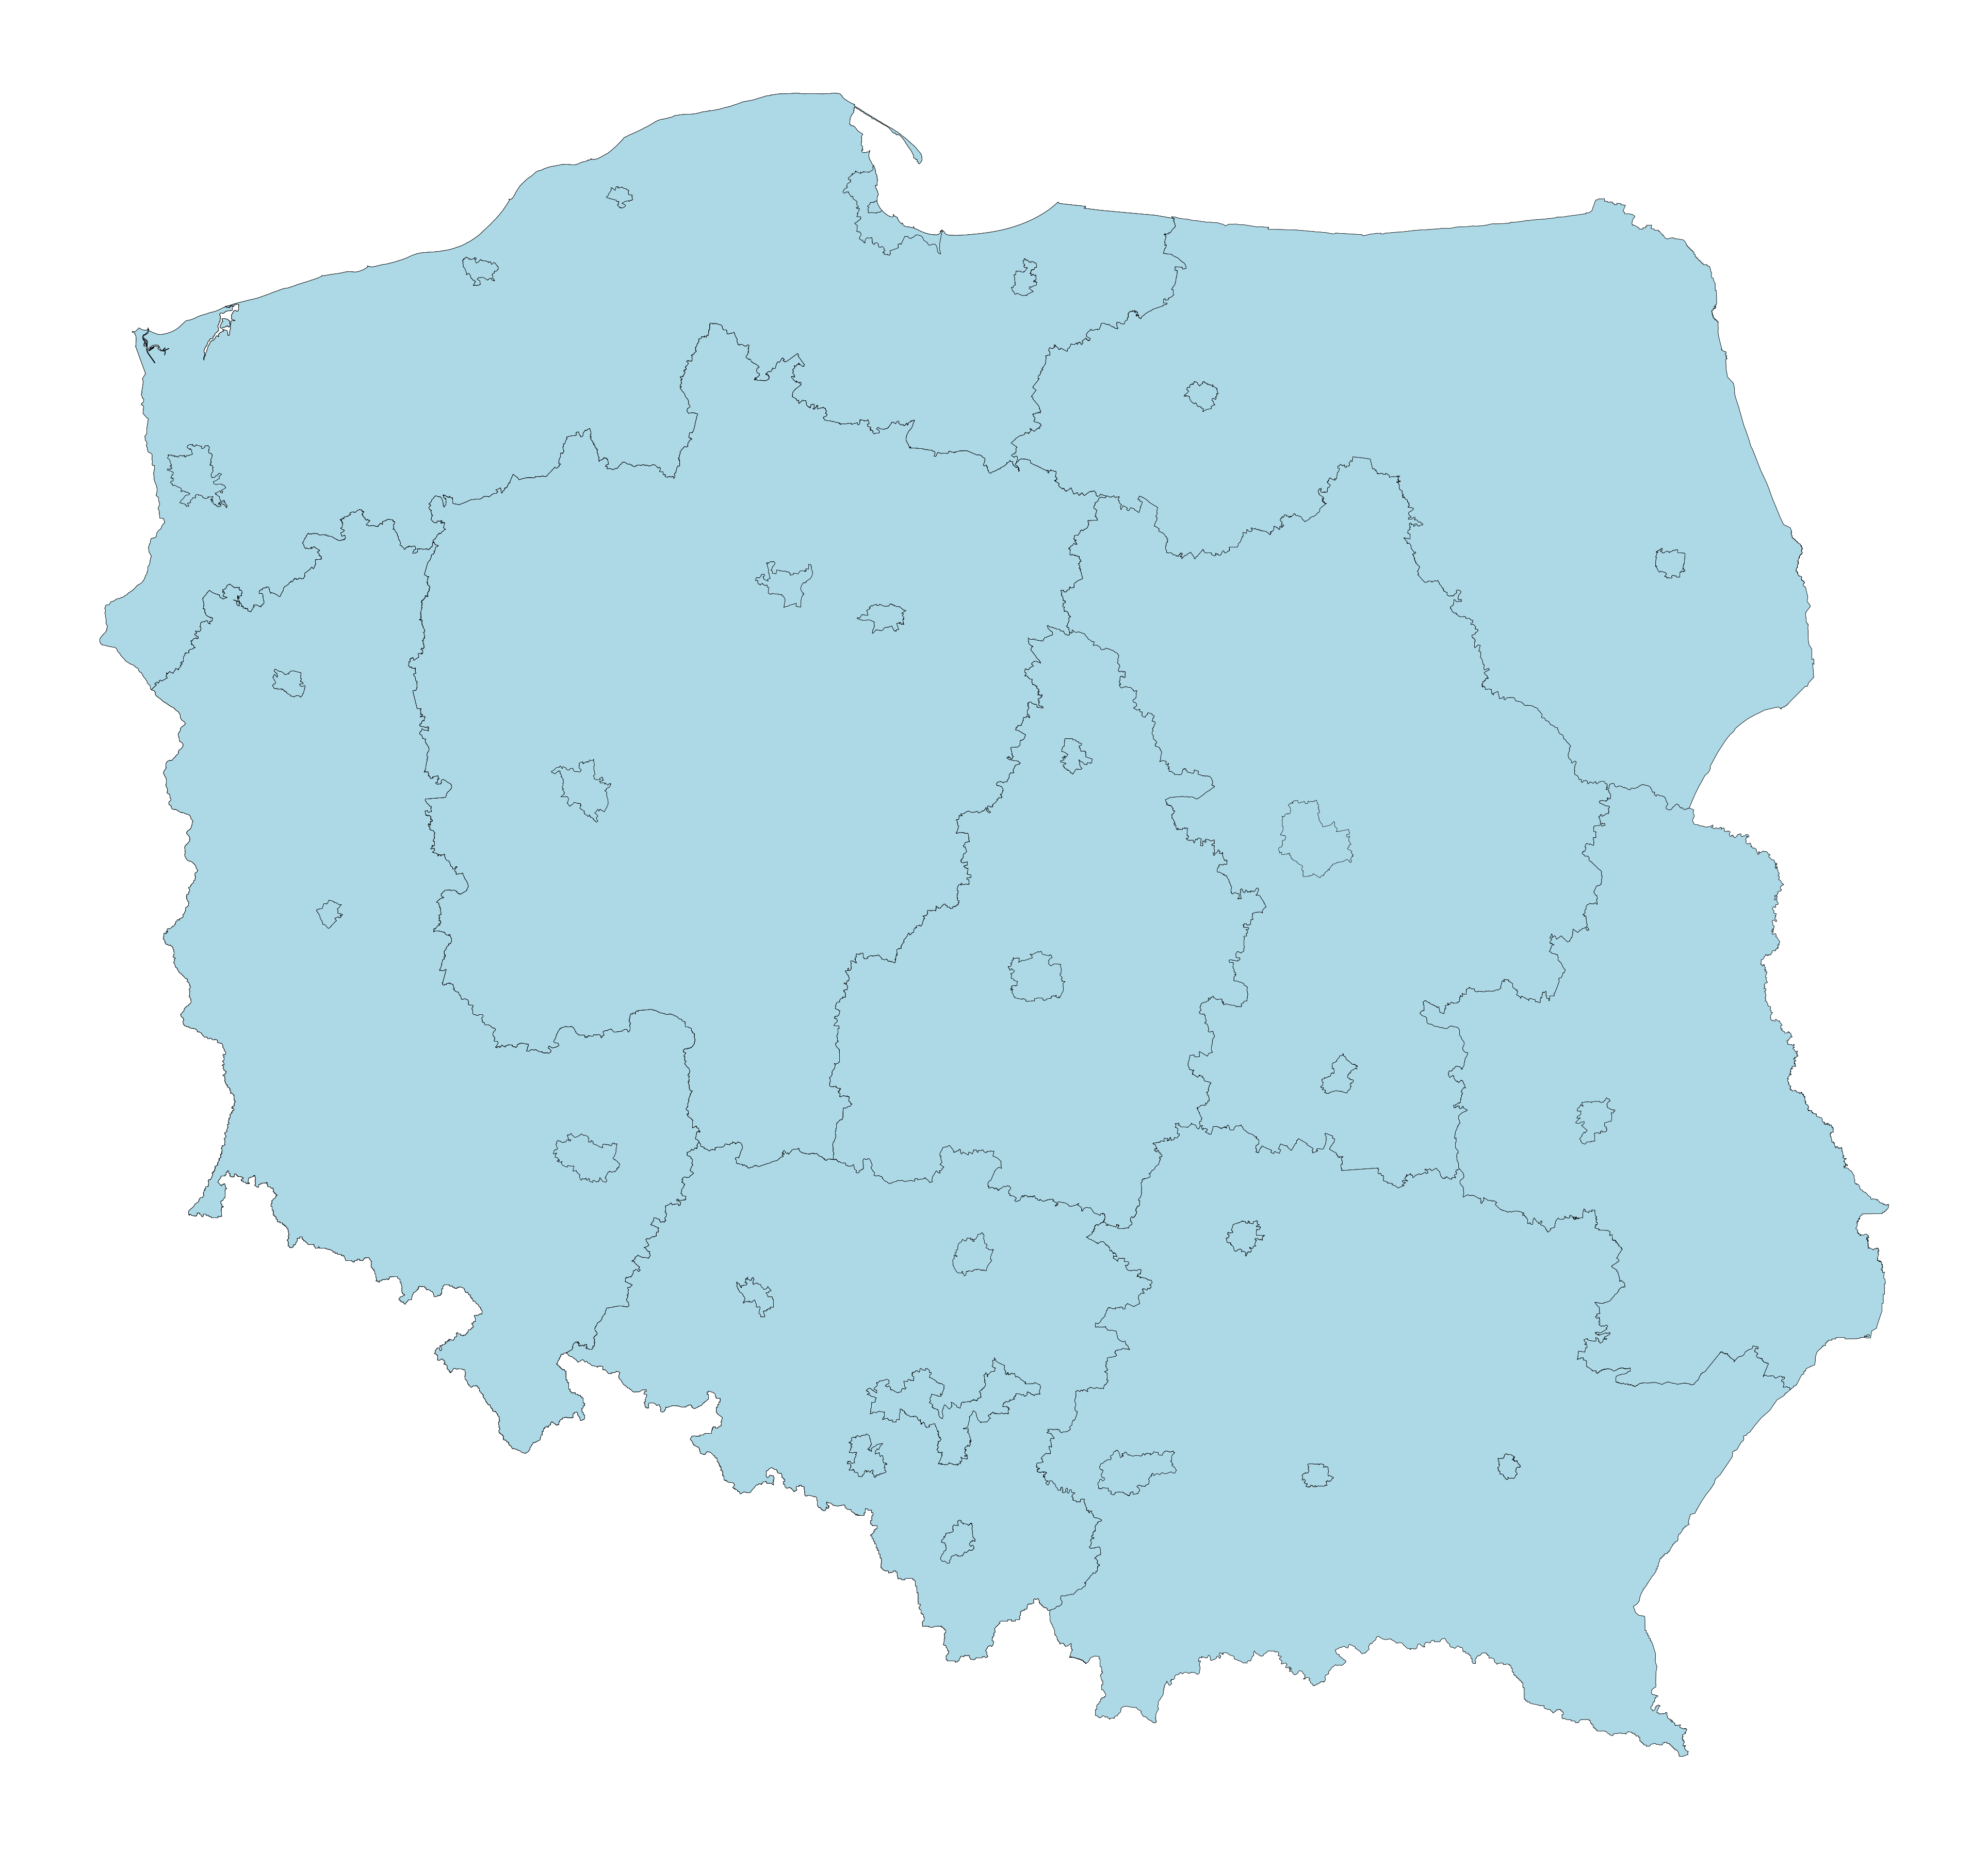

In [17]:
# Plot
fig, ax = plt.subplots(figsize=(20,20), dpi = 200)
group_gdf[group_gdf['if_LIS_macro']].plot(ax=ax, edgecolor='black', color='lightblue', linewidth=0.25)
fig.tight_layout()
ax.set_axis_off()
fig.show()


In [19]:
# Save both to file

region_gdf[region_gdf['if_old']].to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='old_voivodeships', driver='GPKG')
region_gdf[region_gdf['if_new']].to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='new_voivodeships', driver='GPKG')
region_gdf[region_gdf['if_LIS_macro']].to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='LIS_macroregions', driver='GPKG')
region_gdf[region_gdf['if_CBOS_macro']].to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='CBOS_macroregions', driver='GPKG')

group_gdf[group_gdf['if_old']].to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='old_voiv_groups', driver='GPKG')
group_gdf[group_gdf['if_new']].to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='new_voiv_groups', driver='GPKG')
group_gdf[group_gdf['if_LIS_macro']].to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='LIS_macroregion_groups', driver='GPKG')
group_gdf[group_gdf['if_CBOS_macro']].to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='CBOS_macroregion_groups', driver='GPKG')

region_gdf.to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='regions', driver='GPKG')
group_gdf.to_file(os.path.join(REPLICATE_ROOT, 'geometry.gpkg'), layer='groups', driver='GPKG')